Present assumptions:
- psuedobulked on CRE (removing MPRA barcode heterogenaity). 
- untransfected zeroes are detectable and have been removed
- Chimeric transcripts have been removed
- No systemic differences in cell number, tfection efficiency btwn reps (should change)
- There ARE systemic differences in dropout between replicates

In [91]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import seaborn as sns
import itertools

1000


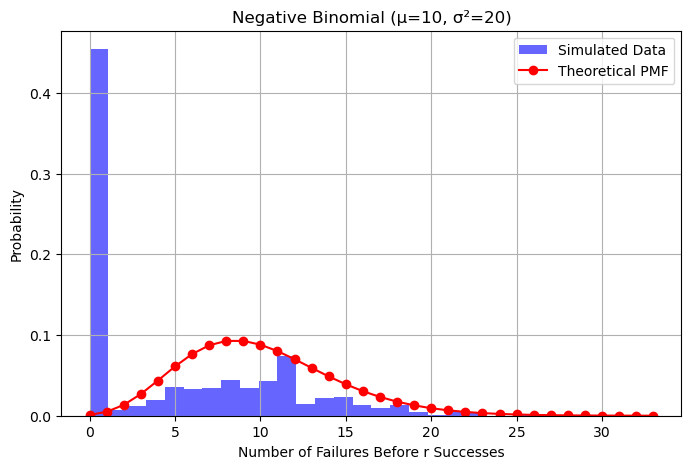

In [92]:

def plot_negative_binomial(samples, mu, sigma2):
    """
    Plot histogram and theoretical PMF of Negative Binomial distribution using mean and variance.
    """
    # Convert mean & variance to standard Negative Binomial parameters
    r = mu**2 / (sigma2 - mu)  # Number of successes
    p = mu / sigma2  # Probability of success

    plt.figure(figsize=(8, 5))
    plt.hist(samples, bins=30, density=True, alpha=0.6, color='b', label="Simulated Data")

    # Overlay theoretical Negative Binomial PMF
    x = np.arange(0, max(samples) + 1)
    pmf = stats.nbinom.pmf(x, r, p)
    plt.plot(x, pmf, 'ro-', label="Theoretical PMF")

    plt.xlabel("Number of Failures Before r Successes")
    plt.ylabel("Probability")
    plt.title(f"Negative Binomial (μ={mu}, σ²={sigma2})")
    plt.legend()
    plt.grid()
    plt.show()

def draw_nb(mu, sigma2, size):
    """
    Draw samples from a Negative Binomial distribution using mean and variance.

    Args:
        mu (float): Desired mean.
        sigma2 (float): Desired variance (must be > mu).
        size (int): Number of samples to draw.

    Returns:
        samples (array): Generated samples.
    """
    if sigma2 <= mu:
        raise ValueError("Variance must be greater than the mean (sigma² > μ)")

    # Convert mean & variance to standard Negative Binomial parameters
    r = mu**2 / (sigma2 - mu)  # Number of successes
    p = mu / sigma2  # Probability of success

    samples = np.random.negative_binomial(n=r, p=p, size=size)
    
    return samples

def draw_zinb(mu, sigma2, zin, size):
    """
        Args:
            mu (float): Desired mean.
            sigma2 (float): Desired variance (must be > mu).
            zin (float): 0-1 Desired fraction zero inflation. 
            size (int): Number of samples to draw.
    """

    zin_size=round(size*zin)
    non_zin_size=size-zin_size
    
    zerolist=pd.Series([0]*zin_size)
    draws=draw_nb(mu=mu,sigma2=sigma2,size=non_zin_size)

    return np.concatenate([zerolist,draws])

# Example usage:
mu = 10  # Mean
sigma2 = 20  # Variance
samples = draw_zinb(mu, sigma2,zin=0.5,size=1000)
print(len(samples))
plot_negative_binomial(samples, mu, sigma2)

In [93]:
cres=pd.read_csv("synthetic_ground_truth.tsv",sep="\t")
cres=cres.sort_values(by=["Cell-type","CRE"])

<Axes: xlabel='Cell-type', ylabel='mean'>

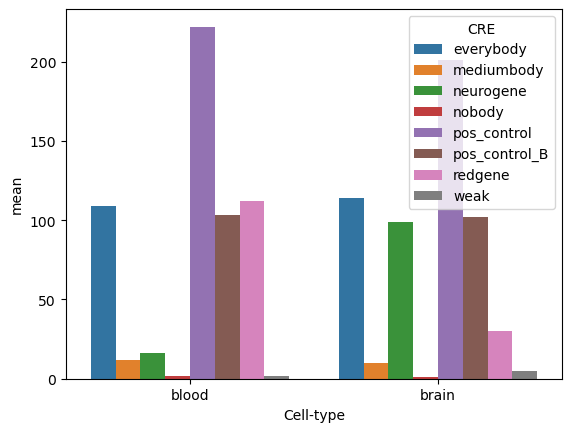

In [94]:
sns.barplot(cres,x="Cell-type",hue="CRE",y="mean")

In [95]:
#add variance column
np.random.seed(111111) # so it's the same every time
cres["variance_constant"] = [0.3]*len(cres)
cres["sigmasquare"]=cres["mean"]+cres["variance_constant"]*cres["mean"]**2

In [96]:
cres

,CRE,Cell-type,mean,variance_constant,sigmasquare
10,everybody,blood,109,0.3,3673.3
9,mediumbody,blood,12,0.3,55.2
12,neurogene,blood,16,0.3,92.8
8,nobody,blood,2,0.3,3.2
14,pos_control,blood,222,0.3,15007.2
15,pos_control_B,blood,103,0.3,3285.7
11,redgene,blood,112,0.3,3875.2
13,weak,blood,2,0.3,3.2
2,everybody,brain,114,0.3,4012.8
1,mediumbody,brain,10,0.3,40.0


In [97]:
#add alterantive parametrization
cres["r"]=cres["mean"]**2/(cres["sigmasquare"]-cres["mean"])#also equal to 1/cres["variance_constant"]
cres["p"]=cres["mean"]/cres["sigmasquare"]

In [98]:
cres

,CRE,Cell-type,mean,variance_constant,sigmasquare,r,p
10,everybody,blood,109,0.3,3673.3,3.333333,0.029674
9,mediumbody,blood,12,0.3,55.2,3.333333,0.217391
12,neurogene,blood,16,0.3,92.8,3.333333,0.172414
8,nobody,blood,2,0.3,3.2,3.333333,0.625000
14,pos_control,blood,222,0.3,15007.2,3.333333,0.014793
15,pos_control_B,blood,103,0.3,3285.7,3.333333,0.031348
11,redgene,blood,112,0.3,3875.2,3.333333,0.028902
13,weak,blood,2,0.3,3.2,3.333333,0.625000
2,everybody,brain,114,0.3,4012.8,3.333333,0.028409
1,mediumbody,brain,10,0.3,40.0,3.333333,0.250000


In [99]:
# at this point, we have all of the information that would be replicate-indepndent. 
# Let's duplicate the table vertically to simulate 

total_reps=3
cres_duplicated = pd.concat([cres] * total_reps, ignore_index=True)
cres_duplicated['replicate_ID'] = [i + 1 for i in range(total_reps) for _ in range(len(cres))]

In [100]:
cres_duplicated

,CRE,Cell-type,mean,variance_constant,sigmasquare,r,p,replicate_ID
0,everybody,blood,109,0.3,3673.3,3.333333,0.029674,1
1,mediumbody,blood,12,0.3,55.2,3.333333,0.217391,1
2,neurogene,blood,16,0.3,92.8,3.333333,0.172414,1
3,nobody,blood,2,0.3,3.2,3.333333,0.625000,1
4,pos_control,blood,222,0.3,15007.2,3.333333,0.014793,1
5,pos_control_B,blood,103,0.3,3285.7,3.333333,0.031348,1
6,redgene,blood,112,0.3,3875.2,3.333333,0.028902,1
7,weak,blood,2,0.3,3.2,3.333333,0.625000,1
8,everybody,brain,114,0.3,4012.8,3.333333,0.028409,1
9,mediumbody,brain,10,0.3,40.0,3.333333,0.250000,1


In [101]:
cres=cres_duplicated

In [102]:
#let's pretend..
#In each replicate there were 1000 blood cells and 900 brain cells, and transfection efficiency for each CRE ~ N(0.5,0.01)
#to be more sophisticated, we could introduce systemic differences in cell number, tfection efficiency btwn reps...
np.random.seed(413) # so it's the same every time
cres["transfection_efficiency"]=np.random.normal(loc=0.5, scale=0.01, size=len(cres))
cres["cells"]=cres["Cell-type"].map({"brain":900,"blood":1000})*cres["transfection_efficiency"]
cres["cells"]=cres["cells"].round().astype(int)

In [103]:

#add zero inflation column
#this represents dropout due to RNA degredation, etc
#RNA dropout for each CRE ~ N(x,0.01) for rep 1 x=0.1, rep 2 x=0.2, rep3 x=0.3

np.random.seed(413)

zeroinfl=[]
for infl in [0.1,0.2,0.3]:
    zeroinfl.append(np.random.normal(loc=infl, scale=0.01, size=int(len(cres)/3)))

cres["zeroinfl"]=np.concatenate(zeroinfl)


In [104]:
cres

,CRE,Cell-type,mean,variance_constant,sigmasquare,r,p,replicate_ID,transfection_efficiency,cells,zeroinfl
0,everybody,blood,109,0.3,3673.3,3.333333,0.029674,1,0.488506,489,0.088506
1,mediumbody,blood,12,0.3,55.2,3.333333,0.217391,1,0.515676,516,0.115676
2,neurogene,blood,16,0.3,92.8,3.333333,0.172414,1,0.501541,502,0.101541
3,nobody,blood,2,0.3,3.2,3.333333,0.625000,1,0.492430,492,0.092430
4,pos_control,blood,222,0.3,15007.2,3.333333,0.014793,1,0.516259,516,0.116259
5,pos_control_B,blood,103,0.3,3285.7,3.333333,0.031348,1,0.499099,499,0.099099
6,redgene,blood,112,0.3,3875.2,3.333333,0.028902,1,0.504306,504,0.104306
7,weak,blood,2,0.3,3.2,3.333333,0.625000,1,0.501417,501,0.101417
8,everybody,brain,114,0.3,4012.8,3.333333,0.028409,1,0.495357,446,0.095357
9,mediumbody,brain,10,0.3,40.0,3.333333,0.250000,1,0.498538,449,0.098538


In [105]:
np.random.seed(612)
def wrapper(row):
    #print(type(row["cells"]))
    return draw_zinb(mu=row["mean"], sigma2=row["sigmasquare"], zin=row["zeroinfl"], size=row["cells"])

cres["draws"]=cres.apply(wrapper,axis=1)


In [106]:
cres

,CRE,Cell-type,mean,variance_constant,sigmasquare,r,p,replicate_ID,transfection_efficiency,cells,zeroinfl,draws
0,everybody,blood,109,0.3,3673.3,3.333333,0.029674,1,0.488506,489,0.088506,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,mediumbody,blood,12,0.3,55.2,3.333333,0.217391,1,0.515676,516,0.115676,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,neurogene,blood,16,0.3,92.8,3.333333,0.172414,1,0.501541,502,0.101541,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,nobody,blood,2,0.3,3.2,3.333333,0.625000,1,0.492430,492,0.092430,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,pos_control,blood,222,0.3,15007.2,3.333333,0.014793,1,0.516259,516,0.116259,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
5,pos_control_B,blood,103,0.3,3285.7,3.333333,0.031348,1,0.499099,499,0.099099,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6,redgene,blood,112,0.3,3875.2,3.333333,0.028902,1,0.504306,504,0.104306,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7,weak,blood,2,0.3,3.2,3.333333,0.625000,1,0.501417,501,0.101417,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
8,everybody,brain,114,0.3,4012.8,3.333333,0.028409,1,0.495357,446,0.095357,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
9,mediumbody,brain,10,0.3,40.0,3.333333,0.250000,1,0.498538,449,0.098538,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [107]:
#shuffle the draws to avoid having all the zeroes lumped together at the front
np.random.seed(413)
cres['draws'] = cres['draws'].apply(lambda x: list(np.random.permutation(x)))


In [108]:
#Subsetting to those data that will be accessible after the assay is performed.
cres_reduced=cres[["CRE","Cell-type","replicate_ID","draws","cells"]]

In [109]:
cres_reduced

,CRE,Cell-type,replicate_ID,draws,cells
0,everybody,blood,1,"[74, 255, 101, 27, 101, 83, 200, 70, 31, 45, 3...",489
1,mediumbody,blood,1,"[20, 12, 7, 0, 0, 13, 2, 8, 2, 2, 6, 10, 4, 8,...",516
2,neurogene,blood,1,"[14, 26, 39, 18, 17, 0, 21, 3, 10, 7, 12, 21, ...",502
3,nobody,blood,1,"[1, 1, 1, 1, 2, 0, 0, 5, 4, 3, 0, 1, 0, 2, 2, ...",492
4,pos_control,blood,1,"[315, 35, 276, 290, 0, 176, 378, 0, 158, 0, 16...",516
5,pos_control_B,blood,1,"[50, 0, 0, 118, 0, 44, 133, 51, 65, 197, 174, ...",499
6,redgene,blood,1,"[41, 80, 84, 173, 76, 72, 105, 120, 47, 28, 77...",504
7,weak,blood,1,"[2, 4, 5, 5, 0, 1, 0, 0, 3, 4, 2, 7, 0, 5, 0, ...",501
8,everybody,brain,1,"[63, 41, 98, 28, 0, 87, 206, 46, 159, 87, 90, ...",446
9,mediumbody,brain,1,"[2, 6, 6, 18, 0, 7, 9, 2, 4, 0, 2, 9, 8, 8, 16...",449


Now let's add cell_bc. Each combination of replicate, cell_id gets its own set of cell barcodes.

In [110]:
#for each combination of col values that represents one set of cells, we wish to get the max number of cells
cell_sets=cres_reduced.groupby(["Cell-type","replicate_ID"])['cells'].agg('max')
cell_sets

Cell-type  replicate_ID
blood      1               516
           2               522
           3               513
brain      1               465
           2               471
           3               470
Name: cells, dtype: int64

In [111]:
def generate_barcodes(length, count):
    if 4**length < count:
        raise ValueError("Not enough unique barcodes of given length.")

    digit_to_base = ['A', 'C', 'G', 'T']
    barcodes = []

    for i in range(count):
        barcode = []
        n = i
        for _ in range(length):
            barcode.append(digit_to_base[n % 4])
            n //= 4
        # If length not fully filled, pad with 'A's
        while len(barcode) < length:
            barcode.append('A')
        barcodes.append(''.join(reversed(barcode)))

    return barcodes

barcodes=generate_barcodes(16,cell_sets.sum())

In [112]:
def assign_barcodes(df, barcodes):
    assigned = []
    i = 0
    for num in df['cells']:
        assigned.append(barcodes[i : i + num])
        i += num
    df = df.copy()
    df['assigned_barcodes'] = assigned
    return df

assignation=assign_barcodes(pd.DataFrame(cell_sets).reset_index(),barcodes)

In [113]:
assignation

,Cell-type,replicate_ID,cells,assigned_barcodes
0,blood,1,516,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
1,blood,2,522,"[AAAAAAAAAAAGAACA, AAAAAAAAAAAGAACC, AAAAAAAAA..."
2,blood,3,513,"[AAAAAAAAAACAAATG, AAAAAAAAAACAAATT, AAAAAAAAA..."
3,brain,1,465,"[AAAAAAAAAACGAATT, AAAAAAAAAACGACAA, AAAAAAAAA..."
4,brain,2,471,"[AAAAAAAAAACTTGAA, AAAAAAAAAACTTGAC, AAAAAAAAA..."
5,brain,3,470,"[AAAAAAAAAAGCGTCT, AAAAAAAAAAGCGTGA, AAAAAAAAA..."


In [114]:
assert all(assignation["assigned_barcodes"].apply(len)==assignation["cells"])

Nice! ok, let's add to cres_reduced

In [115]:
assignation=pd.merge(cres_reduced,assignation,how="left",on=["Cell-type","replicate_ID"])#.explode(['draws','assigned_barcodes']).reset_index(drop=True)
assignation

,CRE,Cell-type,replicate_ID,draws,cells_x,cells_y,assigned_barcodes
0,everybody,blood,1,"[74, 255, 101, 27, 101, 83, 200, 70, 31, 45, 3...",489,516,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
1,mediumbody,blood,1,"[20, 12, 7, 0, 0, 13, 2, 8, 2, 2, 6, 10, 4, 8,...",516,516,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
2,neurogene,blood,1,"[14, 26, 39, 18, 17, 0, 21, 3, 10, 7, 12, 21, ...",502,516,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
3,nobody,blood,1,"[1, 1, 1, 1, 2, 0, 0, 5, 4, 3, 0, 1, 0, 2, 2, ...",492,516,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
4,pos_control,blood,1,"[315, 35, 276, 290, 0, 176, 378, 0, 158, 0, 16...",516,516,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
5,pos_control_B,blood,1,"[50, 0, 0, 118, 0, 44, 133, 51, 65, 197, 174, ...",499,516,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
6,redgene,blood,1,"[41, 80, 84, 173, 76, 72, 105, 120, 47, 28, 77...",504,516,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
7,weak,blood,1,"[2, 4, 5, 5, 0, 1, 0, 0, 3, 4, 2, 7, 0, 5, 0, ...",501,516,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
8,everybody,brain,1,"[63, 41, 98, 28, 0, 87, 206, 46, 159, 87, 90, ...",446,465,"[AAAAAAAAAACGAATT, AAAAAAAAAACGACAA, AAAAAAAAA..."
9,mediumbody,brain,1,"[2, 6, 6, 18, 0, 7, 9, 2, 4, 0, 2, 9, 8, 8, 16...",449,465,"[AAAAAAAAAACGAATT, AAAAAAAAAACGACAA, AAAAAAAAA..."


In [116]:
assignation=assignation.drop("cells_y",axis=1).rename({'cells_x':'cells'},axis=1)

In [117]:
def trunk(row):
    return row["assigned_barcodes"][0:row["cells"]]
assignation["assigned_barcodes"]=assignation.apply(trunk,axis=1)

In [118]:
assignation

,CRE,Cell-type,replicate_ID,draws,cells,assigned_barcodes
0,everybody,blood,1,"[74, 255, 101, 27, 101, 83, 200, 70, 31, 45, 3...",489,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
1,mediumbody,blood,1,"[20, 12, 7, 0, 0, 13, 2, 8, 2, 2, 6, 10, 4, 8,...",516,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
2,neurogene,blood,1,"[14, 26, 39, 18, 17, 0, 21, 3, 10, 7, 12, 21, ...",502,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
3,nobody,blood,1,"[1, 1, 1, 1, 2, 0, 0, 5, 4, 3, 0, 1, 0, 2, 2, ...",492,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
4,pos_control,blood,1,"[315, 35, 276, 290, 0, 176, 378, 0, 158, 0, 16...",516,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
5,pos_control_B,blood,1,"[50, 0, 0, 118, 0, 44, 133, 51, 65, 197, 174, ...",499,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
6,redgene,blood,1,"[41, 80, 84, 173, 76, 72, 105, 120, 47, 28, 77...",504,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
7,weak,blood,1,"[2, 4, 5, 5, 0, 1, 0, 0, 3, 4, 2, 7, 0, 5, 0, ...",501,"[AAAAAAAAAAAAAAAA, AAAAAAAAAAAAAAAC, AAAAAAAAA..."
8,everybody,brain,1,"[63, 41, 98, 28, 0, 87, 206, 46, 159, 87, 90, ...",446,"[AAAAAAAAAACGAATT, AAAAAAAAAACGACAA, AAAAAAAAA..."
9,mediumbody,brain,1,"[2, 6, 6, 18, 0, 7, 9, 2, 4, 0, 2, 9, 8, 8, 16...",449,"[AAAAAAAAAACGAATT, AAAAAAAAAACGACAA, AAAAAAAAA..."


In [119]:
cres_reduced=assignation.explode(['draws', 'assigned_barcodes']).reset_index(drop=True)

In [120]:
cres_reduced

,CRE,Cell-type,replicate_ID,draws,cells,assigned_barcodes
0,everybody,blood,1,74,489,AAAAAAAAAAAAAAAA
1,everybody,blood,1,255,489,AAAAAAAAAAAAAAAC
2,everybody,blood,1,101,489,AAAAAAAAAAAAAAAG
3,everybody,blood,1,27,489,AAAAAAAAAAAAAAAT
4,everybody,blood,1,101,489,AAAAAAAAAAAAAACA
...,...,...,...,...,...,...
22860,weak,brain,3,3,455,AAAAAAAAAAGTCTGC
22861,weak,brain,3,0,455,AAAAAAAAAAGTCTGG
22862,weak,brain,3,0,455,AAAAAAAAAAGTCTGT
22863,weak,brain,3,0,455,AAAAAAAAAAGTCTTA


In [121]:
def check_barcode_uniqueness(df, group_by_col):
    from itertools import combinations

    grouped = df.groupby(group_by_col)['assigned_barcodes'].agg(set)

    for (group1, barcodes1), (group2, barcodes2) in combinations(grouped.items(), 2):
        overlap = barcodes1 & barcodes2
        if overlap:
            print(f"[!] Overlapping barcodes between {group1} and {group2}:")
            print(f"   {len(overlap)} overlapping barcodes (e.g. {list(overlap)[:5]})")
            return False

    print(f"[+] All {group_by_col} groups have unique barcode sets.")
    return True

assert check_barcode_uniqueness(cres_reduced,"Cell-type")
assert check_barcode_uniqueness(cres_reduced,"replicate_ID")

[+] All Cell-type groups have unique barcode sets.
[+] All replicate_ID groups have unique barcode sets.


In [122]:
#one we expect to have overlap:
assert not check_barcode_uniqueness(cres_reduced,"CRE")

[!] Overlapping barcodes between everybody and mediumbody:
   2824 overlapping barcodes (e.g. ['AAAAAAAAAACGATAT', 'AAAAAAAAAACGGTCC', 'AAAAAAAAAACGGTTT', 'AAAAAAAAAAATCGCT', 'AAAAAAAAAAACGCCA'])


In [123]:
cres_reduced=cres_reduced.rename({'draws':'umis_mpra_bc','replicate_ID':'rep_id','assigned_barcodes':'cell_bc','CRE':'cre_id','Cell-type':'cell_type'},axis=1)[["cell_bc","rep_id","cre_id","cell_type","umis_mpra_bc"]]

In [124]:
cres_reduced

,cell_bc,rep_id,cre_id,cell_type,umis_mpra_bc
0,AAAAAAAAAAAAAAAA,1,everybody,blood,74
1,AAAAAAAAAAAAAAAC,1,everybody,blood,255
2,AAAAAAAAAAAAAAAG,1,everybody,blood,101
3,AAAAAAAAAAAAAAAT,1,everybody,blood,27
4,AAAAAAAAAAAAAACA,1,everybody,blood,101
...,...,...,...,...,...
22860,AAAAAAAAAAGTCTGC,3,weak,brain,3
22861,AAAAAAAAAAGTCTGG,3,weak,brain,0
22862,AAAAAAAAAAGTCTGT,3,weak,brain,0
22863,AAAAAAAAAAGTCTTA,3,weak,brain,0


In [125]:
agg=pd.DataFrame(cres_reduced.groupby(["cre_id","cell_type"])['umis_mpra_bc'].agg('sum')).reset_index()

In [126]:
agg

,cre_id,cell_type,umis_mpra_bc
0,everybody,blood,128754
1,everybody,brain,125947
2,mediumbody,blood,13923
3,mediumbody,brain,10895
4,neurogene,blood,19001
5,neurogene,brain,102742
6,nobody,blood,2330
7,nobody,brain,1097
8,pos_control,blood,270653
9,pos_control,brain,218769


<Axes: xlabel='cell_type', ylabel='umis_mpra_bc'>

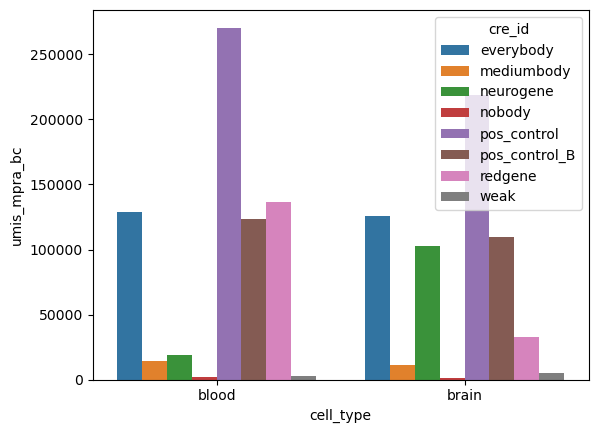

In [127]:
sns.barplot(agg.sort_values(by=["cell_type","cre_id"]),x="cell_type",hue="cre_id",y="umis_mpra_bc")

In [128]:
cres_reduced.to_csv("/gpfs/gibbs/pi/reilly/tabula_data/simulated/fake_cres_v2.tsv",sep="\t")